In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import pandas_ta as ta


In [62]:
PRIMARY_THRESHOLD = 0.55
META_THRESHOLD = 0.55
META_TRAIN_FRAC = 0.30

CSV_PATH = "EURUSD_Candlestick_5_M_ASK_30.09.2019-30.09.2022.csv"

N_ROWS = 30000

BARS = 20
D_FRAC = 0.3
SLCOEF = 1.0
TPSL_RATIO = 1.0

TRAIN_SIZE = 5000
TEST_SIZE = 2500
EMBARGO = BARS

PRIMARY_THRESHOLD = 0.55
META_THRESHOLD = 0.55
META_TRAIN_FRAC = 0.30

MAX_ATR_RANK = 0.80
MIN_TREND_STRENGTH = 0.50
MAX_VOL_RATIO = 1.80
USE_VOL_RATIO_FILTER = True

In [63]:
# =========================
# LOAD DATA
# =========================

df = pd.read_csv(CSV_PATH)
df = df.loc[:N_ROWS].copy().reset_index(drop=True)

for col in ["Open", "High", "Low", "Close", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Open", "High", "Low", "Close"]).reset_index(drop=True)

In [64]:
df["ret_3"] = df["Close"].pct_change(3)
df["ret_6"] = df["Close"].pct_change(6)
df["ret_12"] = df["Close"].pct_change(12)

df["ema_50"] = df["Close"].ewm(span=50).mean()
df["ema_200"] = df["Close"].ewm(span=200).mean()

df["trend_filter"] = (df["ema_50"] > df["ema_200"]).astype(int)

df["alpha_momentum"] = (
    df["ret_3"]
    + df["ret_6"]
    + df["ret_12"]
)

In [65]:
signal = (
    (df["trend_filter"] == 1)
    & (df["alpha_momentum"] > df["alpha_momentum"].rolling(500).quantile(0.70))
)

In [66]:
df["ema_50"] = df["Close"].ewm(span=50).mean()
df["ema_200"] = df["Close"].ewm(span=200).mean()
df["rsi_14"] = ta.rsi(df["Close"], length=14)

df["uptrend"] = df["ema_50"] > df["ema_200"]

signal = (
    df["uptrend"]
    & (df["rsi_14"] < 40)
    & (df["Close"] > df["ema_200"])
)

In [67]:
df["range_20"] = df["High"].rolling(20).max() - df["Low"].rolling(20).min()
df["range_100"] = df["High"].rolling(100).max() - df["Low"].rolling(100).min()

df["compression"] = df["range_20"] / df["range_100"]

df["breakout_high"] = df["High"].rolling(20).max().shift(1)

signal = (
    (df["compression"] < df["compression"].rolling(500).quantile(0.25))
    & (df["Close"] > df["breakout_high"])
)

In [68]:
df["Gmt time"] = pd.to_datetime(df["Gmt time"])
df["hour"] = df["Gmt time"].dt.hour
df["minute"] = df["Gmt time"].dt.minute

df["london_session"] = df["hour"].between(7, 11)
df["ny_overlap"] = df["hour"].between(12, 16)

/var/folders/ll/24hn928n4q3g2p7xsf4mn31c0000gn/T/ipykernel_5718/2193257230.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M:%S.%f format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Gmt time"] = pd.to_datetime(df["Gmt time"])


In [69]:
session_filter = df["london_session"] | df["ny_overlap"]

In [70]:
df["ret_1"] = df["Close"].pct_change()

df["ema_50"] = df["Close"].ewm(span=50, adjust=False).mean()
df["ema_200"] = df["Close"].ewm(span=200, adjust=False).mean()

df["rsi_14"] = ta.rsi(df["Close"], length=14)

df["atr"] = ta.atr(df["High"], df["Low"], df["Close"], length=14)
df["atr_pct"] = df["atr"] / df["Close"]
df["atr_rank"] = df["atr_pct"].rolling(500).rank(pct=True)

df["uptrend"] = df["ema_50"] > df["ema_200"]
df["pullback"] = df["rsi_14"] < 40
df["vol_ok"] = df["atr_rank"] < 0.80

alpha_signal = (
    df["uptrend"]
    & df["pullback"]
    & df["vol_ok"]
).astype(int)

In [71]:
df["alpha_signal"] = alpha_signal

events = df[df["alpha_signal"] == 1].copy()

print(events.shape)
display(events.head())

(1609, 30)


,Gmt time,Open,High,Low,Close,Volume,ret_3,ret_6,ret_12,ema_50,...,minute,london_session,ny_overlap,ret_1,atr,atr_pct,atr_rank,pullback,vol_ok,alpha_signal
556,2019-10-01 22:20:00,1.09315,1.09321,1.09304,1.09310,230.59,-0.000137,-0.000210,-0.000329,1.093303,...,20,False,False,-0.000055,0.000227,0.000208,0.334,True,True,1
570,2019-10-01 23:30:00,1.09312,1.09312,1.09300,1.09305,195.76,-0.000027,-0.000091,-0.000091,1.093239,...,30,False,False,-0.000064,0.000147,0.000135,0.112,True,True,1
606,2019-10-02 02:30:00,1.09365,1.09368,1.09335,1.09336,350.05,-0.000256,-0.000274,-0.000421,1.093634,...,30,False,False,-0.000265,0.000148,0.000135,0.134,True,True,1
626,2019-10-02 04:10:00,1.09349,1.09349,1.09330,1.09338,403.73,-0.000256,-0.000320,-0.000146,1.093636,...,10,False,False,-0.000091,0.000136,0.000125,0.102,True,True,1
627,2019-10-02 04:15:00,1.09338,1.09344,1.09332,1.09341,328.56,-0.000219,-0.000265,-0.000201,1.093627,...,15,False,False,0.000027,0.000135,0.000124,0.100,True,True,1


In [72]:
META_BARS = 24

future_ret = (
    events["Close"]
    .shift(-META_BARS)
    / events["Close"]
    - 1
)

events["meta_label"] = (
    future_ret > 0.0005
).astype(int)

In [73]:
feature_cols = [
    "ret_1",
    "rsi_14",
    "atr_pct",
    "atr_rank",
    "ema_50",
    "ema_200",
]

In [74]:
events = events.dropna(subset=feature_cols + ["meta_label"]).reset_index(drop=True)

In [75]:
TRAIN_SIZE = 800
TEST_SIZE = 200
EMBARGO = META_BARS

In [76]:
print("Events:", len(events))
print("Need at least:", TRAIN_SIZE + EMBARGO + TEST_SIZE)

if len(events) < TRAIN_SIZE + EMBARGO + TEST_SIZE:
    raise ValueError(
        "Not enough alpha events. Reduce TRAIN_SIZE/TEST_SIZE or loosen alpha_signal."
    )

Events: 1609
Need at least: 1024


In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import xgboost as xgb

results = []

n = len(events)

for start in range(
    0,
    n - TRAIN_SIZE - EMBARGO - TEST_SIZE + 1,
    TEST_SIZE
):

    # =========================
    # WALK-FORWARD SPLITS
    # =========================

    train = events.iloc[start : start + TRAIN_SIZE]

    test = events.iloc[
        start + TRAIN_SIZE + EMBARGO :
        start + TRAIN_SIZE + EMBARGO + TEST_SIZE
    ]

    # =========================
    # FEATURES / LABELS
    # =========================

    X_train_raw = train[feature_cols]
    y_train = train["meta_label"]

    X_test_raw = test[feature_cols]
    y_test = test["meta_label"]

    # =========================
    # SCALING
    # =========================

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # =========================
    # PCA
    # =========================

    pca = PCA(n_components=0.95)

    X_train = pca.fit_transform(X_train_scaled)
    X_test = pca.transform(X_test_scaled)

    # =========================
    # XGBOOST
    # =========================

    clf = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )

    clf.fit(X_train, y_train)

    # =========================
    # PREDICTIONS
    # =========================

    proba = clf.predict_proba(X_test)[:, 1]

    signal = (proba >= 0.55).astype(int)

    # =========================
    # STORE RESULTS
    # =========================

    fold_df = pd.DataFrame({
        "y_true": y_test.values,
        "proba": proba,
        "signal": signal,
    })

    results.append(fold_df)

    print(
        f"Fold done | "
        f"Train: {len(train)} | "
        f"Test: {len(test)} | "
        f"PCA comps: {pca.n_components_}"
    )

ml_results = pd.concat(results, ignore_index=True)

print(ml_results.head())

Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
Fold done | Train: 800 | Test: 200 | PCA comps: 4
   y_true     proba  signal
0       0  0.180628       0
1       0  0.077221       0
2       0  0.226121       0
3       0  0.150406       0
4       1  0.113140       0


In [78]:
train

,Gmt time,Open,High,Low,Close,Volume,ret_3,ret_6,ret_12,ema_50,...,london_session,ny_overlap,ret_1,atr,atr_pct,atr_rank,pullback,vol_ok,alpha_signal,meta_label
400,2019-11-01 09:10:00,1.11547,1.11552,1.11536,1.11537,515.02,-0.000636,-0.000502,-0.001146,1.116107,...,True,False,-0.000081,0.000284,0.000254,0.602,True,True,1,1
401,2019-11-01 09:15:00,1.11537,1.11549,1.11527,1.11528,569.69,-0.000430,-0.000699,-0.000914,1.116075,...,True,False,-0.000081,0.000279,0.000250,0.590,True,True,1,1
402,2019-11-01 09:20:00,1.11528,1.11529,1.11504,1.11514,470.32,-0.000287,-0.000681,-0.000833,1.116038,...,True,False,-0.000126,0.000277,0.000248,0.588,True,True,1,1
403,2019-11-01 09:25:00,1.11514,1.11514,1.11497,1.11497,419.55,-0.000359,-0.000995,-0.000726,1.115996,...,True,False,-0.000152,0.000269,0.000242,0.574,True,True,1,1
404,2019-11-01 09:30:00,1.11498,1.11517,1.11497,1.11517,533.00,-0.000099,-0.000529,-0.000448,1.115964,...,True,False,0.000179,0.000264,0.000237,0.568,True,True,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2020-01-07 00:55:00,1.11927,1.11927,1.11894,1.11901,260.57,-0.000152,-0.000339,-0.000491,1.119412,...,False,False,-0.000232,0.000138,0.000123,0.090,True,True,1,0
1196,2020-01-07 01:00:00,1.11900,1.11913,1.11897,1.11910,320.72,0.000027,-0.000205,-0.000277,1.119400,...,False,False,0.000080,0.000139,0.000124,0.092,True,True,1,0
1197,2020-01-07 04:55:00,1.11933,1.11934,1.11907,1.11912,258.36,-0.000161,-0.000179,-0.000107,1.119317,...,False,False,-0.000179,0.000106,0.000094,0.022,True,True,1,0
1198,2020-01-07 05:00:00,1.11913,1.11914,1.11904,1.11911,198.01,-0.000188,-0.000179,-0.000152,1.119309,...,False,False,-0.000009,0.000105,0.000094,0.022,True,True,1,0


In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train[feature_cols])
X_test_scaled = scaler.transform(test[feature_cols])

pca = PCA(n_components=0.95)

X_train = pca.fit_transform(X_train_scaled)
X_test = pca.transform(X_test_scaled)

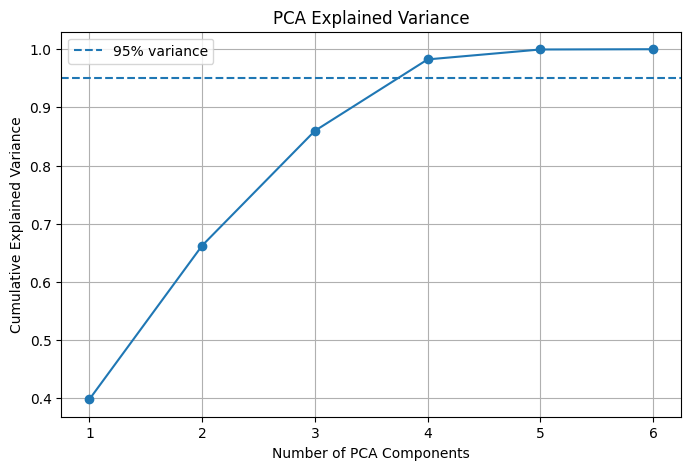

In [80]:
pca_full = PCA()

pca_full.fit(X_train_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker="o"
)

plt.axhline(0.95, linestyle="--", label="95% variance")

plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.legend()

plt.show()

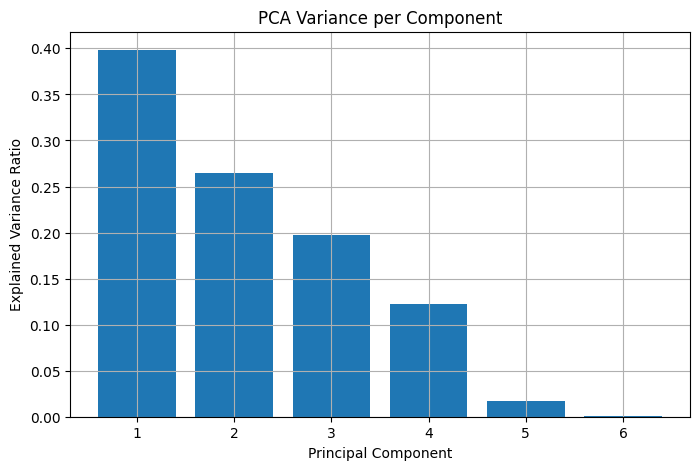

In [81]:
explained = pca_full.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.bar(
    range(1, len(explained)+1),
    explained
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Variance per Component")

plt.grid(True)

plt.show()

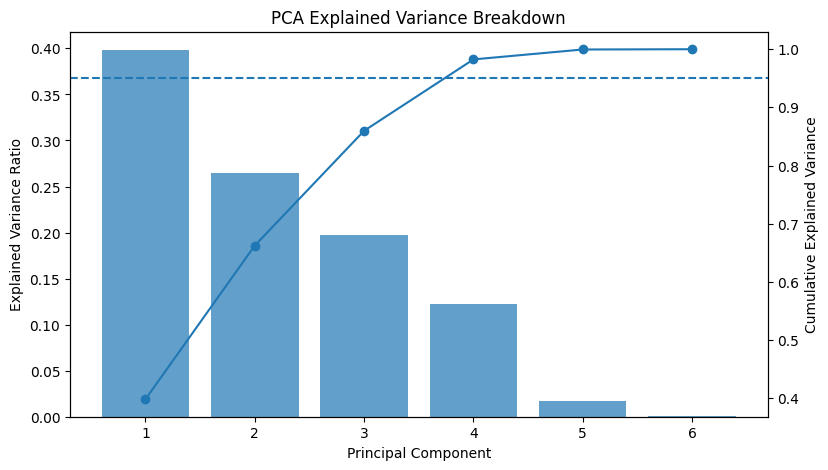

In [82]:
cum_var = np.cumsum(explained)

fig, ax1 = plt.subplots(figsize=(9,5))

ax1.bar(
    range(1, len(explained)+1),
    explained,
    alpha=0.7,
    label="Individual"
)

ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")

ax2 = ax1.twinx()

ax2.plot(
    range(1, len(cum_var)+1),
    cum_var,
    marker="o",
    label="Cumulative"
)

ax2.axhline(0.95, linestyle="--")

ax2.set_ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance Breakdown")

plt.show()

In [83]:
loadings = pd.DataFrame(
    pca_full.components_,
    columns=feature_cols,
    index=[f"PC{i+1}" for i in range(len(feature_cols))]
)

display(loadings)

,ret_1,rsi_14,atr_pct,atr_rank,ema_50,ema_200
PC1,-0.134192,-0.005033,0.521519,0.364952,0.537876,0.536176
PC2,-0.303693,-0.068854,0.398923,0.602211,-0.435290,-0.437899
PC3,0.589751,0.763617,0.172734,0.174635,-0.061112,-0.070804
PC4,0.736055,-0.640334,0.108111,0.187090,-0.031344,-0.022849
PC5,0.013330,-0.044783,0.726160,-0.662240,-0.134524,-0.117685
PC6,-0.001260,0.009481,-0.006750,0.009509,-0.705973,0.708078


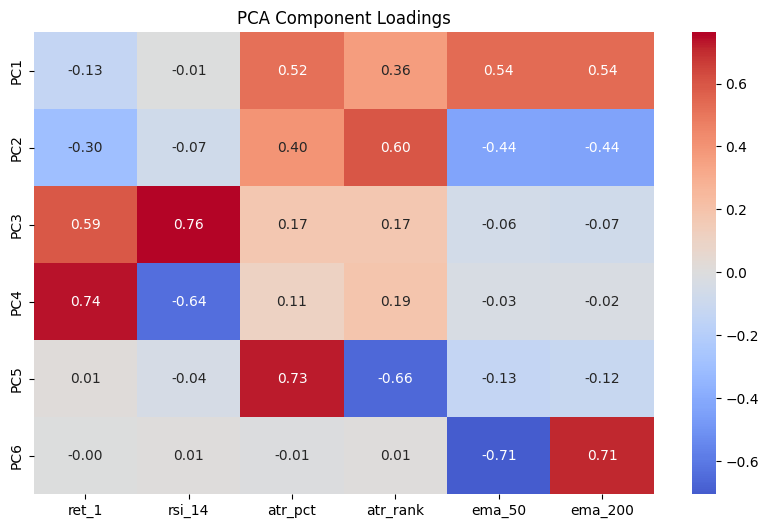

In [84]:
plt.figure(figsize=(10,6))

sns.heatmap(
    loadings,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("PCA Component Loadings")

plt.show()

In [85]:
META_BARS = 24

future_ret = (
    events["Close"].shift(-META_BARS)
    / events["Close"]
    - 1
)

events["meta_label"] = (
    future_ret > 0.0005
).astype(int)

In [86]:
MIN_EVENT_GAP = META_BARS

events = events.iloc[
    np.arange(0, len(events), MIN_EVENT_GAP)
].copy()

In [87]:
# 1. Add new features to df FIRST

for k in [3, 6, 12, 24]:
    df[f"ret_{k}"] = df["Close"].pct_change(k)

df["dist_high_50"] = df["Close"] / df["High"].rolling(50).max()
df["dist_low_50"] = df["Close"] / df["Low"].rolling(50).min()

df["atr_change"] = df["atr_pct"].diff()

In [93]:
df.tail()

,Gmt time,Open,High,Low,Close,Volume,ret_3,ret_6,ret_12,ema_50,...,atr,atr_pct,atr_rank,pullback,vol_ok,alpha_signal,ret_24,dist_high_50,dist_low_50,atr_change
29996,2020-02-24 19:50:00,1.08474,1.08490,1.08459,1.08464,301.85,-0.000138,-0.000866,-0.001390,1.085604,...,0.000379,0.000349,0.668,True,True,1,-0.002153,0.997627,1.000452,-0.000005
29997,2020-02-24 19:55:00,1.08465,1.08492,1.08424,1.08433,561.28,-0.000516,-0.001023,-0.001915,1.085554,...,0.000400,0.000369,0.732,True,True,1,-0.002557,0.997342,1.000166,0.000020
29998,2020-02-24 20:00:00,1.08434,1.08471,1.08415,1.08466,488.42,-0.000074,-0.000433,-0.001464,1.085519,...,0.000412,0.000380,0.754,True,True,1,-0.002153,0.997645,1.000470,0.000010
29999,2020-02-24 20:05:00,1.08465,1.08478,1.08456,1.08465,371.41,0.000009,-0.000129,-0.001133,1.085485,...,0.000398,0.000367,0.720,True,True,1,-0.002208,0.997636,1.000461,-0.000013
30000,2020-02-24 20:10:00,1.08468,1.08481,1.08459,1.08476,265.45,0.000397,-0.000120,-0.001096,1.085456,...,0.000385,0.000355,0.676,True,True,1,-0.002134,0.997737,1.000563,-0.000012


In [96]:
feature_cols = [
    "ret_1",
    "rsi_14",
    "atr_pct",
    "atr_rank",
    "ema_50",
    "ema_200",
    "ret_3",
    "ret_6",
    "ret_12",
    "ret_24",
    "dist_high_50",
    "dist_low_50",
    "atr_change",
]

missing = [c for c in feature_cols if c not in df.columns]
print("Missing from df:", missing)

Missing from df: []


In [99]:
feature_cols = [

    # =========================
    # ORIGINAL FEATURES
    # =========================

    "ret_1",
    "rsi_14",
    "atr_pct",
    "atr_rank",
    "ema_50",
    "ema_200",

    # =========================
    # MULTI-HORIZON MOMENTUM
    # =========================

    "ret_3",
    "ret_6",
    "ret_12",
    "ret_24",

    # =========================
    # DISTANCE FROM EXTREMES
    # =========================

    "dist_high_50",
    "dist_low_50",

    # =========================
    # VOLATILITY ACCELERATION
    # =========================

    "atr_change",
]

In [101]:
events.tail()

,Gmt time,Open,High,Low,Close,Volume,ret_3,ret_6,ret_12,ema_50,...,london_session,ny_overlap,ret_1,atr,atr_pct,atr_rank,pullback,vol_ok,alpha_signal,meta_label
1512,2020-02-17 11:30:00,1.08417,1.08417,1.08398,1.08412,445.77,-0.000277,-0.000387,-0.000433,1.084355,...,True,False,-0.000055,0.000218,0.000201,0.640,True,True,1,0
1536,2020-02-20 02:05:00,1.08023,1.08023,1.08008,1.08015,285.41,0.000157,-0.000259,-0.000990,1.080676,...,False,False,-0.000065,0.000258,0.000238,0.564,True,True,1,1
1560,2020-02-21 21:15:00,1.08490,1.08493,1.08486,1.08487,100.86,-0.000074,-0.000055,-0.000636,1.085169,...,False,False,-0.000037,0.000164,0.000151,0.214,True,True,1,0
1584,2020-02-24 01:10:00,1.08298,1.08298,1.08265,1.08267,503.29,-0.000443,-0.000397,-0.001089,1.083820,...,False,False,-0.000286,0.000292,0.000269,0.436,True,True,1,1
1608,2020-02-24 20:10:00,1.08468,1.08481,1.08459,1.08476,265.45,0.000397,-0.000120,-0.001096,1.085456,...,False,False,0.000101,0.000385,0.000355,0.676,True,True,1,0


In [ ]:
# feature_cols = [
#     "ret_1",
#     "rsi_14",
#     "atr_pct",
#     "atr_rank",
#     "ema_50",
#     "ema_200",
#     "ret_3",
#     "ret_6",
#     "ret_12",
#     "ret_24",
#     "dist_high_50",
#     "dist_low_50",
#     "atr_change",
#     "london_session",
#     "ny_overlap",
# ]

# missing = [c for c in feature_cols if c not in events.columns]
# print("Missing:", missing)

# events = events.dropna(
#     subset=feature_cols + ["meta_label"]
# ).reset_index(drop=True)

# print("Events:", len(events))
# print(events["meta_label"].value_counts())
# print("Base rate:", events["meta_label"].mean())

Missing: ['ret_24', 'dist_high_50', 'dist_low_50', 'atr_change']


KeyError: ['ret_24', 'dist_high_50', 'dist_low_50', 'atr_change']

In [104]:
# 1. Add missing features to df

df["ret_24"] = df["Close"].pct_change(24)

df["dist_high_50"] = df["Close"] / df["High"].rolling(50).max()
df["dist_low_50"] = df["Close"] / df["Low"].rolling(50).min()

df["atr_change"] = df["atr_pct"].diff()

In [106]:
# 2. Recreate events from updated df

events = df[df["alpha_signal"] == 1].copy()

META_BARS = 24

future_ret = events["Close"].shift(-META_BARS) / events["Close"] - 1
events["meta_label"] = (future_ret > 0.0005).astype(int)

In [107]:
events = events.dropna(
    subset=feature_cols + ["meta_label"]
).reset_index(drop=True)

In [ ]:
# 3. Define features and clean

feature_cols = [
    "ret_1",
    "rsi_14",
    "atr_pct",
    "atr_rank",
    "ema_50",
    "ema_200",
    "ret_3",
    "ret_6",
    "ret_12",
    "ret_24",
    "dist_high_50",
    "dist_low_50",
    "atr_change",
    "london_session",
    "ny_overlap",
]

missing = [c for c in feature_cols if c not in events.columns]
print("Missing:", missing)

events = events.dropna(
    subset=feature_cols + ["meta_label"]
).reset_index(drop=True)

print("Events:", len(events))
print(events["meta_label"].value_counts())
print("Base rate:", events["meta_label"].mean())

Missing: []
Events: 1609
meta_label
0    946
1    663
Name: count, dtype: int64
Base rate: 0.4120571783716594


In [109]:
TRAIN_SIZE = 800
TEST_SIZE = 200
EMBARGO = 24

In [112]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
)

import xgboost as xgb

results = []

n = len(events)

fold = 0

for start in range(
    0,
    n - TRAIN_SIZE - EMBARGO - TEST_SIZE + 1,
    TEST_SIZE
):

    fold += 1

    # =========================
    # WALK-FORWARD SPLITS
    # =========================

    train = events.iloc[start : start + TRAIN_SIZE]

    test = events.iloc[
        start + TRAIN_SIZE + EMBARGO :
        start + TRAIN_SIZE + EMBARGO + TEST_SIZE
    ]

    # =========================
    # FEATURES / LABELS
    # =========================

    X_train_raw = train[feature_cols]
    y_train = train["meta_label"]

    X_test_raw = test[feature_cols]
    y_test = test["meta_label"]

    # =========================
    # SCALING
    # =========================

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # =========================
    # PCA
    # =========================

    pca = PCA(n_components=0.95)

    X_train = pca.fit_transform(X_train_scaled)
    X_test = pca.transform(X_test_scaled)

    # =========================
    # MODEL
    # =========================

    clf = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )

    clf.fit(X_train, y_train)

    # =========================
    # PREDICTIONS
    # =========================

    proba = clf.predict_proba(X_test)[:,1]

    # signal = (proba > 0.55).astype(int)
    TOP_K_FRAC = 0.10   # approve top 10% of candidate events in each test fold

    k = max(1, int(len(proba) * TOP_K_FRAC))

    signal = np.zeros(len(proba), dtype=int)

    top_idx = np.argsort(proba)[-k:]

    signal[top_idx] = 1

    # =========================
    # STORE RESULTS
    # =========================

    fold_df = pd.DataFrame({
        "fold": fold,
        "y_true": y_test.values,
        "proba": proba,
        "signal": signal,
    })

    results.append(fold_df)

    print(
        f"Fold {fold} | "
        f"Train {len(train)} | "
        f"Test {len(test)} | "
        f"PCA comps {pca.n_components_}"
    )

ml_results = pd.concat(results, ignore_index=True)

print(ml_results.head())

Fold 1 | Train 800 | Test 200 | PCA comps 10
Fold 2 | Train 800 | Test 200 | PCA comps 10
Fold 3 | Train 800 | Test 200 | PCA comps 10
   fold  y_true     proba  signal
0     1       0  0.087439       0
1     1       0  0.057480       0
2     1       0  0.299666       0
3     1       0  0.306725       0
4     1       1  0.116716       0


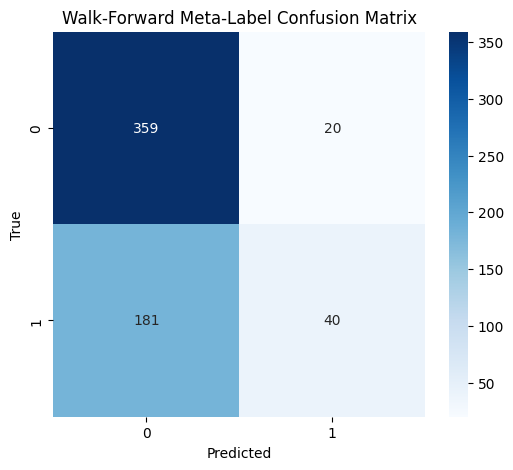

              precision    recall  f1-score   support

           0       0.66      0.95      0.78       379
           1       0.67      0.18      0.28       221

    accuracy                           0.67       600
   macro avg       0.67      0.56      0.53       600
weighted avg       0.67      0.67      0.60       600



In [113]:
cm = confusion_matrix(
    ml_results["y_true"],
    ml_results["signal"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Walk-Forward Meta-Label Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

print(classification_report(
    ml_results["y_true"],
    ml_results["signal"],
    zero_division=0
))